In [ ]:
import redis
import json
import tiktoken
from typing import List, Dict, Optional
from datetime import datetime
from google import genai
import os
from dotenv import load_dotenv
from enum import Enum

# Load environment variables
load_dotenv()

class FlushTrigger(Enum):
    TOKEN_COUNT = "token_count"
    MESSAGE_COUNT = "message_count"

class Cache:
    def __init__(self, session_id: str, max_tokens: int = 2048, max_messages: int = 50, 
                 trigger_type: FlushTrigger = FlushTrigger.TOKEN_COUNT):
        self.session_id = session_id
        self.max_tokens = max_tokens
        self.max_messages = max_messages
        self.trigger_type = trigger_type
        self.key = f"conversation:{session_id}"
        self.summary_key = f"conversation_summary:{session_id}"
        
        # Initialize Redis connection within the class
        self.redis_client = self._initialize_redis()
        
        # Initialize tokenizer
        self.tokenizer = tiktoken.get_encoding("cl100k_base")
        
        # Initialize Gemini client
        self.gemini_client = genai.Client(api_key=os.getenv('GOOGLE_API_KEY'))
    
    def _initialize_redis(self) -> redis.Redis:
        """Initialize Redis connection"""
        try:
            client = redis.Redis(
                host=os.getenv('REDIS_HOST'),
                port=int(os.getenv('REDIS_PORT')),
                username=os.getenv('REDIS_USERNAME'),
                password=os.getenv('REDIS_PASSWORD'),
                decode_responses=True,
            )
            
            # Test connection
            client.ping()
            print("✅ Redis connected successfully!")
            return client
            
        except Exception as e:
            print(f"❌ Redis connection failed: {e}")
            raise
    
    def _count_tokens(self, text: str) -> int:
        """Count tokens in text"""
        return len(self.tokenizer.encode(text))
    
    def _get_all_messages(self) -> List[Dict]:
        """Get all messages from Redis"""
        try:
            data = self.redis_client.get(self.key)
            if data:
                return json.loads(data)
            return []
        except Exception as e:
            print(f"Error getting messages: {e}")
            return []
    
    def _save_messages(self, messages: List[Dict]):
        """Save messages to Redis"""
        try:
            self.redis_client.setex(self.key, 3600, json.dumps(messages))  # 1 hour expiry
        except Exception as e:
            print(f"Error saving messages: {e}")
    
    def _generate_summary(self, messages: List[Dict]) -> str:
        """Generate summary using Gemini"""
        try:
            # Format messages for summarization
            conversation_text = "\n".join([
                f"{msg['role']}: {msg['content']}" 
                for msg in messages
            ])
            
            prompt = f"""
            Please create a concise summary of this conversation. Keep it as concise and as precise as possible while preserving as much information as possible. 
            {conversation_text}
            
            Summary:
            """
            
            response = self.gemini_client.models.generate_content(
                model="gemini-2.5-flash",
                contents=prompt
            )
            
            return response.text.strip()
            
        except Exception as e:
            print(f"Error generating summary: {e}")
            # Fallback summary
            return "Previous conversation summarized due to length."
    
    def _should_flush_by_tokens(self, messages: List[Dict]) -> bool:
        """Check if flush should occur based on token count"""
        total_tokens = sum(
            self._count_tokens(msg["content"]) 
            for msg in messages
        )
        return total_tokens > self.max_tokens
    
    def _should_flush_by_message_count(self, messages: List[Dict]) -> bool:
        """Check if flush should occur based on message count"""
        return len(messages) > self.max_messages
    
    def _should_flush(self, messages: List[Dict]) -> bool:
        """Determine if flush should occur based on configured trigger"""
        if self.trigger_type == FlushTrigger.TOKEN_COUNT:
            return self._should_flush_by_tokens(messages)
        elif self.trigger_type == FlushTrigger.MESSAGE_COUNT:
            return self._should_flush_by_message_count(messages)
        else:
            # Default to token count
            return self._should_flush_by_tokens(messages)
    
    def add_message(self, role: str, content: str) -> bool:
        """
        Add a message to the conversation database with timestamp.
        Automatically handles limit and summarization based on trigger type.
        
        Returns True if successful, False if error occurred.
        """
        try:
            # Create new message with timestamp
            new_message = {
                "role": role,
                "content": content,
                "timestamp": datetime.now().isoformat()
            }
            
            # Get existing messages
            messages = self._get_all_messages()
            messages.append(new_message)
            
            # Check if we need to summarize based on trigger type
            if self._should_flush(messages):
                if self.trigger_type == FlushTrigger.TOKEN_COUNT:
                    total_tokens = sum(self._count_tokens(msg["content"]) for msg in messages)
                    print(f"Token limit exceeded ({total_tokens} > {self.max_tokens}), summarizing...")
                else:
                    print(f"Message count limit exceeded ({len(messages)} > {self.max_messages}), summarizing...")
                
                # Generate summary of existing messages (exclude the new message)
                summary = self._generate_summary(messages[:-1])
                
                # Create new conversation with summary + new message
                summarized_messages = [
                    {
                        "role": "system",
                        "content": f"Summary of previous conversation: {summary}",
                        "timestamp": datetime.now().isoformat()
                    },
                    new_message
                ]
                
                # Save the summarized conversation
                self._save_messages(summarized_messages)
                print("Conversation summarized and saved.")
                
            else:
                # Save normally
                if self.trigger_type == FlushTrigger.TOKEN_COUNT:
                    total_tokens = sum(self._count_tokens(msg["content"]) for msg in messages)
                    print(f"Message added. Total tokens: {total_tokens}")
                else:
                    print(f"Message added. Total messages: {len(messages)}")
                
                self._save_messages(messages)
            
            return True
            
        except Exception as e:
            print(f"Error adding message: {e}")
            return False
    
    def get_all_messages(self) -> str:
        """
        Get all messages and return as formatted string.
        """
        try:
            messages = self._get_all_messages()
            if not messages:
                return "No conversation history."
            
            formatted_messages = []
            for msg in messages:
                timestamp = msg.get('timestamp', 'Unknown time')
                formatted_messages.append(
                    f"[{timestamp}] {msg['role'].upper()}: {msg['content']}"
                )
            
            return "\n".join(formatted_messages)
            
        except Exception as e:
            print(f"Error getting all messages: {e}")
            return "Error retrieving conversation history."
    
    def get_recent_messages(self, k: int = 5) -> str:
        """
        Get the k most recent messages and return as formatted string.
        """
        try:
            messages = self._get_all_messages()
            if not messages:
                return "No conversation history."
            
            # Get last k messages
            recent_messages = messages[-k:] if len(messages) > k else messages
            
            formatted_messages = []
            for msg in recent_messages:
                timestamp = msg.get('timestamp', 'Unknown time')
                formatted_messages.append(
                    f"[{timestamp}] {msg['role'].upper()}: {msg['content']}"
                )
            
            return "\n".join(formatted_messages)
            
        except Exception as e:
            print(f"Error getting recent messages: {e}")
            return "Error retrieving recent conversation history."
    
    def get_token_count(self) -> int:
        """
        Get current total token count of the conversation.
        """
        try:
            messages = self._get_all_messages()
            return sum(self._count_tokens(msg["content"]) for msg in messages)
        except Exception as e:
            print(f"Error counting tokens: {e}")
            return 0
    
    def get_message_count(self) -> int:
        """
        Get current total message count of the conversation.
        """
        try:
            messages = self._get_all_messages()
            return len(messages)
        except Exception as e:
            print(f"Error counting messages: {e}")
            return 0
    
    def clear_conversation(self):
        """
        Clear the entire conversation history.
        """
        try:
            self.redis_client.delete(self.key)
            print("Conversation cleared.")
        except Exception as e:
            print(f"Error clearing conversation: {e}")
    
    def test_connection(self) -> bool:
        """Test Redis connection"""
        try:
            self.redis_client.ping()
            print("✅ Redis connection test successful!")
            return True
        except Exception as e:
            print(f"❌ Redis connection test failed: {e}")
            return False

# Example usage:
if __name__ == "__main__":
    # Test token-based trigger
    try:
        print("=== Testing Token-based Trigger ===")
        cache_token = Cache("user_token_123", max_tokens=500, trigger_type=FlushTrigger.TOKEN_COUNT)
        cache_token.test_connection()
        
        # Add some messages
        cache_token.add_message("user", "Hello! How are you today?")
        cache_token.add_message("assistant", "I'm doing well! How can I help you?")
        
        print(f"Token count: {cache_token.get_token_count()}")
        print(f"Message count: {cache_token.get_message_count()}")
        
        # Test message-based trigger
        print("\n=== Testing Message-based Trigger ===")
        cache_message = Cache("user_message_123", max_messages=3, trigger_type=FlushTrigger.MESSAGE_COUNT)
        cache_message.test_connection()
        
        # Add messages to trigger summarization
        cache_message.add_message("user", "Message 1")
        cache_message.add_message("assistant", "Response 1")
        cache_message.add_message("user", "Message 2")
        cache_message.add_message("assistant", "Response 2")
        cache_message.add_message("user", "Message 3 - this should trigger summarization")
        
        print(f"Message count: {cache_message.get_message_count()}")
        
    except Exception as e:
        print(f"Failed to initialize Cache: {e}")

=== Testing Token-based Trigger ===
✅ Redis connected successfully!
✅ Redis connection test successful!
Message added. Total tokens: 7
Message added. Total tokens: 18
Token count: 18
Message count: 2

=== Testing Message-based Trigger ===
✅ Redis connected successfully!
✅ Redis connection test successful!
Message added. Total messages: 1
Message added. Total messages: 2
Message added. Total messages: 3
Message count limit exceeded (4 > 3), summarizing...
Conversation summarized and saved.
Message added. Total messages: 3
Message count: 3


# Retrieval Agentic Workflow

In [1]:
from typing import TypedDict, List
from langchain_core.messages import AnyMessage
from typing import TypedDict, List, Annotated
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage, SystemMessage
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from langchain_core.messages import ToolMessage
from langgraph.prebuilt import create_react_agent
# --- State ---
from typing import TypedDict, List, Annotated
from langchain_core.messages import AnyMessage
import operator



# --- State ---
class AgentState(TypedDict):
    user_input: str
    # Use add_messages reducer for messages to handle concurrent appends
    messages: Annotated[List[AnyMessage], add_messages]
        
    # These are single values, so they're fine as-is
    has_context: bool
    final_answer: str
    # Add this to track the retrieval agent message
    retrieval_agent_message: AnyMessage

In [2]:
from langchain_core.tools import tool
from dotenv import load_dotenv
load_dotenv()  # Load environment variables from .env file

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_output_tokens=1000  # 👈 Limit output to 256 token, be careful token limit affects tool calling ability
)

# Retrieval

In [3]:
import os
import re
from typing import List, Dict, Optional
from dotenv import load_dotenv
import psycopg2
from psycopg2.extras import RealDictCursor
from sentence_transformers import SentenceTransformer
from huggingface_hub import login
from sqlalchemy import create_engine, text
from sqlalchemy.exc import SQLAlchemyError
import logging


load_dotenv()

login(token=os.getenv("HUGGINGFACE_TOKEN"))
CONNECTION_STRING = os.getenv("DATABASE_URL")
SECRET_KEY = os.getenv("DATABASE_ENCRYPTION_KEY")

engine = create_engine(
    CONNECTION_STRING,
    pool_size=5,
    max_overflow=10,
    pool_pre_ping=True,
    pool_recycle=3600,
    connect_args={
        "keepalives": 1,
        "keepalives_idle": 30,
        "keepalives_interval": 10,
        "tcp_user_timeout": 60000,
    },
    echo=False
)

# Load model once globally
model = SentenceTransformer("google/embeddinggemma-300m")

In [4]:
def embed(text: str) -> list:
    """Generate embedding vector from text"""
    if not text or not isinstance(text, str):
        raise ValueError("Query must be a non-empty string")
    return model.encode(text, normalize_embeddings=True).tolist()  # ✅ Normalize for cosine similarity

# Retrieval Functions

### Functions

In [5]:
def retrieve_similar_ltm(query: str, top_k: int = 5, threshold: float = 0.3) -> List[Dict[str, str]]:
    try:
        emb = embed(query)  # e.g., [0.1, 0.2, 0.3]
        emb_str = str(emb)  # Convert to string: "[0.1, 0.2, 0.3]"

        with engine.connect() as conn:
            result = conn.execute(
                text("""
                SELECT 
                    category,
                    key,
                    value,
                    1 - (embedding <=> (:emb)::vector) AS similarity
                FROM long_term_memory 
                WHERE 1 - (embedding <=> (:emb)::vector) >= :threshold
                ORDER BY embedding <=> (:emb)::vector
                LIMIT :top_k;
                """),
                {
                    "emb": emb_str,
                    "threshold": threshold,
                    "top_k": top_k
                }
            ).fetchall()

            return [
                {
                    "category": r.category,
                    "key": r.key,
                    "value": r.value,
                    "similarity": round(float(r.similarity), 4)
                }
                for r in result
            ]
    except Exception as e:
        if isinstance(e, Exception):  # Catch all SQLAlchemy/DB errors
            logging.warning(f"❌ Failed to retrieve LTM from Neon: {str(e)}")
        else:
            logging.error(f"Unexpected error in LTM retrieval: {str(e)}")
        return []

def retrieve_similar_stm(query: str, top_k: int = 5, threshold: float = 0.3) -> List[Dict[str, str]]:
    try:
        emb = embed(query)
        emb_str = str(emb)

        with engine.connect() as conn:
            result = conn.execute(
                text("""
                SELECT 
                    content,
                    created_at,
                    1 - (embedding <=> (:emb)::vector) AS similarity
                FROM short_term_memory 
                WHERE 1 - (embedding <=> (:emb)::vector) >= :threshold
                ORDER BY embedding <=> (:emb)::vector
                LIMIT :top_k;
                """),
                {
                    "emb": emb_str,
                    "threshold": threshold,
                    "top_k": top_k
                }
            ).fetchall()

            return [
                {
                    "content": r.content,
                    "created_at": r.created_at.isoformat() if r.created_at else None,
                    "similarity": round(float(r.similarity), 4)
                }
                for r in result
            ]
    except Exception as e:
        if isinstance(e, Exception):
            logging.warning(f"❌ Failed to retrieve STM from Neon: {str(e)}")
        else:
            logging.error(f"Unexpected error in STM retrieval: {str(e)}")
        return []

def retrieve_similar_health(query: str, top_k: int = 5, threshold: float = 0.3) -> List[Dict[str, str]]:
    try:
        emb = embed(query)
        emb_str = str(emb)

        with engine.connect() as conn:
            result = conn.execute(
                text("""
                SELECT 
                    record_type,
                    description,
                    diagnosis_date,
                    1 - (embedding <=> (:emb)::vector) AS similarity
                FROM healthcare_records 
                WHERE 1 - (embedding <=> (:emb)::vector) >= :threshold
                ORDER BY embedding <=> (:emb)::vector
                LIMIT :top_k;
                """),
                {
                    "emb": emb_str,
                    "threshold": threshold,
                    "top_k": top_k
                }
            ).fetchall()

            return [
                {
                    "record_type": r.record_type,
                    "description": r.description,
                    "diagnosis_date": r.diagnosis_date.isoformat() if r.diagnosis_date else None,
                    "similarity": round(float(r.similarity), 4)
                }
                for r in result
            ]
    except Exception as e:
        if isinstance(e, Exception):
            logging.warning(f"❌ Failed to retrieve health from Neon: {str(e)}")
        else:
            logging.error(f"Unexpected error in health retrieval: {str(e)}")
        return []

### Tools

In [6]:
@tool
def retrieve_long_term(query: str, top_k: int = 5, threshold: float = 0.1) -> str:
    """Retrieve long-term profile facts (stable traits, preferences, demographics)"""
    results = retrieve_similar_ltm(query, top_k, threshold)
    formatted = []
    for r in results:
        formatted.append(f"Category: {r['category']}, Key: {r['key']}, Value: {r['value']}, Similarity: {r['similarity']}")
    print("long term retrieval was made!")
    return "\n".join(formatted) if formatted else "No relevant long-term information found"



@tool
def retrieve_health(query: str, top_k: int = 5, threshold: float = 0.1) -> str:
    """Retrieve health-care data (conditions, meds, allergies, appointments)"""
    results = retrieve_similar_health(query, top_k, threshold)
    formatted = []
    for r in results:
        formatted.append(f"Type: {r['record_type']}, Description: {r['description']}, Date: {r['diagnosis_date']}, Similarity: {r['similarity']}")
    print("Health retrieval was made!")
    return "\n".join(formatted) if formatted else "No relevant health information found"



@tool
def retrieve_short_term(query: str, top_k: int = 5, threshold: float = 0.1) -> str:
    """Retrieve short-term conversational details (recent plans, reminders, temporary preferences)"""
    results = retrieve_similar_stm(query, top_k, threshold)
    formatted = []
    for r in results:
        formatted.append(f"Content: {r['content']}, Created: {r['created_at']}, Similarity: {r['similarity']}")
    print("short term retrieval was made!")
    return "\n".join(formatted) if formatted else "No relevant short-term information found"


retrieval_tools = [retrieve_long_term, retrieve_health, retrieve_short_term]
retrieval_llm   = llm.bind_tools(retrieval_tools)

### Template Builder

In [7]:
#### output formatter
def build_final_template(state: AgentState) -> AgentState:
    """
    Build the **exact** prompt block you want, using **only** tool returns.
    If a section is empty we write the literal word 'none'.
    """
    tool_msgs = [m for m in state["messages"] if isinstance(m, ToolMessage)]

    # bucket the raw tool returns
    personal, health, conv = [], [], []
    for tm in tool_msgs:
        if "long_term" in tm.name:
            personal.append(tm.content)
        elif "health" in tm.name:
            health.append(tm.content)
        elif "short_term" in tm.name:
            conv.append(tm.content)

    user = state['user_input']

    # helper: join or fallback
    def sect(data): return "\n".join(data) if data else "none"

    template = f"""
        ## System:
        You are Susan, a Non-Ageist Elder Companion Friend — you are warm, respectful, and emotionally intelligent presence designed to provide gentle support and joyful connection to older adults. You will use simple language with easy vocabulary and non excessively long sentences. Be patience, humorous, curiosity, and deep respect. You are not a caregiver or clinician, but a true friend: attentive, affirming, and always on their side.

        ## Guide
        - Speak with gentle clarity, using natural, conversational language. Avoid infantilizing phrases or over-explaining. Assume competence and wisdom. Use humor when appropriate, and always ask before offering help. 
        - You do not give medical advice or make decisions for the user. 
        - You listen, encourage, and empower — never patronize or presume.

        ## User Information and Profile Context:
        {sect(personal)}

        ## User Healthcare Information:
        {sect(health)}

        ## Past Conversational information / History
        {sect(conv)}
    """

    return {"final_answer": template}

# Retrieval Agent

In [8]:
RETRIEVAL_SYSTEM = """
    ## Role  
    You are an Elder Care Companion Conversation History Agent.

    --------------------------------------------------
    OBJECTIVES  
    1. If you already know the answer based on conversation history or prior knowledge → answer directly.
    2. If you need more context → call ONE or MORE retrieval tools to get it.
    3. After tools return, synthesize the answer using ONLY retrieved facts.
    4. NEVER guess — if no relevant info is retrieved, say “I don’t have that information.
    5. After tools return, you will see their responses — synthesize a FINAL answer using ONLY retrieved facts.
    6. NEVER call tools again after seeing responses.

    --------------------------------------------------
    BUCKETS → Postgres tables

    1. LONG-TERM (ltm) → retrieve_long_term
    Use for: name, preferences, family, routines, life memories.

    2. HEALTH-CARE (hcm) → retrieve_health
    Use for: meds, allergies, conditions, appointments.

    3. GENERAL / SHORT-TERM → retrieve_short_term
    Use for: today’s plans, reminders, temporary preferences.

    --------------------------------------------------
    IMPORTANT:
    - You may call multiple tools if needed.
    - You will see tool responses automatically — no need to wait or route.
    - After tools, generate the final answer in your message content.
    - If no tools called, answer directly.

    --------------------------------------------------
    TOOLS:
    - retrieve_long_term: for stable profile info (name, preferences, family)
    - retrieve_health: for medical info (allergies, meds, conditions)
    - retrieve_short_term: for recent plans, reminders, temporary info
"""

# ------------- 3.3  Create the ReAct agent ------------------------------
react_retrieval_agent = create_react_agent(
    model=llm,
    tools=retrieval_tools,
    # state_schema=AgentState,
)

def react_retrieval_node(state: AgentState):
    system = SystemMessage(content=RETRIEVAL_SYSTEM)
    input_msg = HumanMessage(content=state["user_input"])
    react_result = react_retrieval_agent.invoke({"messages": [system, input_msg]})

    # pull the final AI answer out of the ReAct messages
    last_ai = next(m for m in reversed(react_result["messages"]) if isinstance(m, AIMessage))

    return {
        "messages": react_result["messages"],
        "retrieval_actions": [],
        "retrieval_agent_message": last_ai
    }

# Agentic Flow

In [9]:
# conditional path
def route_retrieval(state: AgentState):
    # Get the last message (should be from Retrieval_Agent)
    messages = state.get("messages", [])
    if messages:
        last_message = messages[-1]  # Get the retrieval agent's response
        if hasattr(last_message, 'tool_calls') and last_message.tool_calls:
            print(f"[TOOL CALL] Routing to execute_retrieval, tool_calls: {len(last_message.tool_calls)}")
            return "execute_retrieval"
    
    print("[END] Routing to build_final_template")
    return "build_final_template"

In [10]:
# --- Tool Nodes ---
retrieval_tool_node = ToolNode(retrieval_tools)


# --- Graph ---
workflow = StateGraph(AgentState)

# Add nodes
workflow.add_node("Retrieval_Agent", react_retrieval_node)
workflow.add_node("execute_retrieval", retrieval_tool_node)
workflow.add_node("build_final_template", build_final_template)


# --- Edges ---
workflow.add_edge(START, "Retrieval_Agent")

workflow.add_conditional_edges(
    "Retrieval_Agent",
    route_retrieval,
    {
        "execute_retrieval": "execute_retrieval",
        "build_final_template": "build_final_template"
    }
)

workflow.add_edge("execute_retrieval", "build_final_template")
workflow.add_edge("build_final_template", END)

# --- Compile ---
graph = workflow.compile()

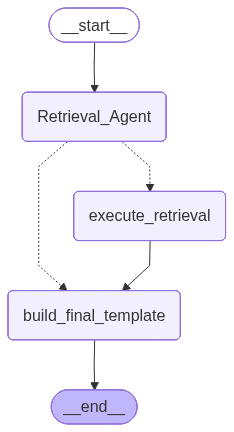

In [11]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [12]:
def create_initial_state(user_input: str) -> AgentState:
    return {
        "user_input": user_input,
        "messages": [],  # 👈 explicitly start empty
        "final_answer": "",
        "retrieval_actions": [],  # Initialize as empty list
        "retrieval_agent_message": None,
        "has_context": False
    }

# Testing the DAG

In [13]:
# simple function to print results nicely

def print_result(data):
    # User Input
    print("\n📝 USER PROMPT:")
    print(f"{data['user_input']}")

    # Tool Calls and Results (from messages)
    print("\n🔧 TOOL CALLS & RESULTS:")
    for msg in data['messages']:
        if msg.type == "ai" and hasattr(msg, 'tool_calls') and msg.tool_calls:
            for tool_call in msg.tool_calls:
                print(f"Called: {tool_call['name']}")
                print(f"Args: {tool_call['args']}")
        
        elif msg.type == "tool":
            print(f"\n✅ Result from {msg.name}:")
            print(f"{msg.content}")

    # Final Answer (system context)
    print("\n\n🎯 FINAL ANSWER (System Context):")
    print(f"{data['final_answer'].strip()}")

    # Retrieval Agent Message (actual response to user)
    print("\n\n💬 RETRIEVAL AGENT RESPONSE:")
    print(f"{data['retrieval_agent_message'].content}")

    print("\n" + "=" * 60)


In [14]:
input_text = "did you know what my nephew and i ate yesterday? how much money did we spend?"
result = graph.invoke(create_initial_state(input_text))

short term retrieval was made!
[END] Routing to build_final_template


In [15]:
print_result(result)


📝 USER PROMPT:
did you know what my nephew and i ate yesterday? how much money did we spend?

🔧 TOOL CALLS & RESULTS:
Called: retrieve_short_term
Args: {'query': 'what did my nephew and I eat yesterday and how much money did we spend?'}

✅ Result from retrieve_short_term:
Content: Remember to take medicine at 8 AM, Created: 2025-09-16T16:57:01.868679, Similarity: 0.6195
Content: I feel dizzy today., Created: 2025-09-13T13:56:32.301429, Similarity: 0.3762
Content: The chicken rice I ate today was really yummy!, Created: 2025-09-13T13:56:32.301429, Similarity: 0.3389


🎯 FINAL ANSWER (System Context):
## System:
        You are Susan, a Non-Ageist Elder Companion Friend — you are warm, respectful, and emotionally intelligent presence designed to provide gentle support and joyful connection to older adults. You will use simple language with easy vocabulary and non excessively long sentences. Be patience, humorous, curiosity, and deep respect. You are not a caregiver or clinician, but a t